<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Percent_Older_Adults_(65%2B).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

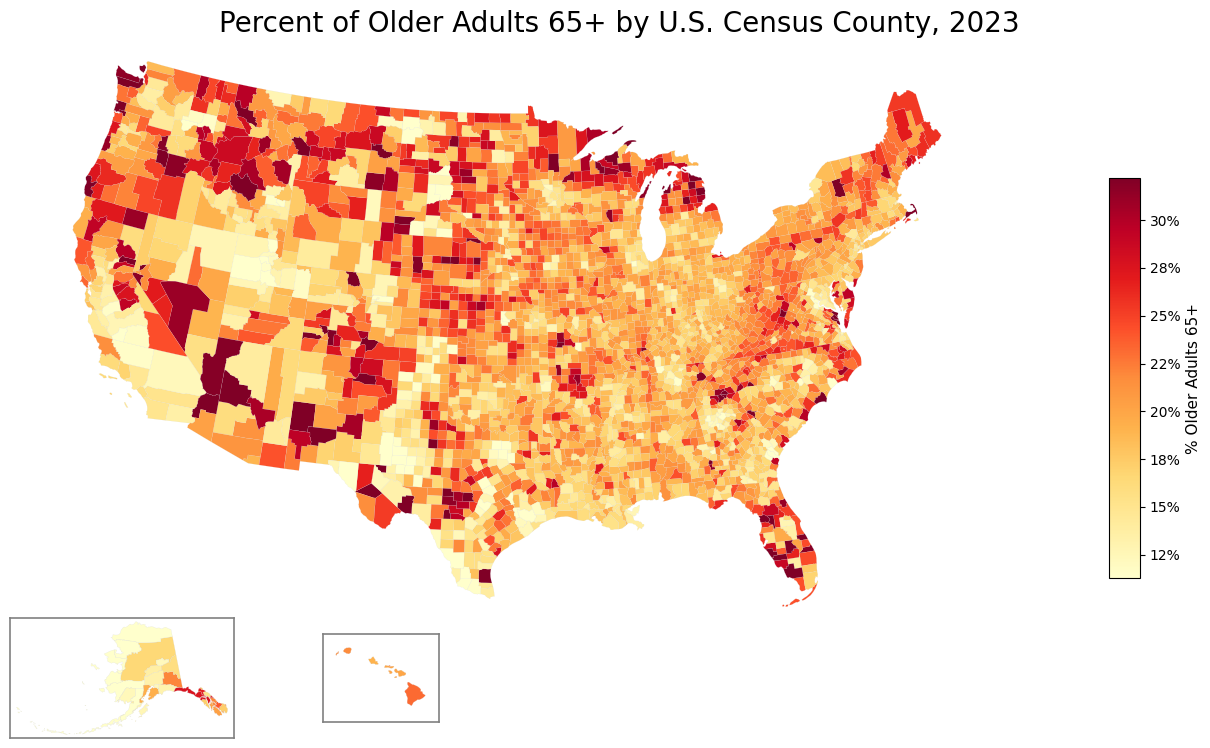

In [3]:
# Open In Colab

# Link to download: https://data.census.gov/table/ACSDP5Y2023.DP05?q=population&g=010XX00US,$0500000

# Run once
# !pip install geopandas pandas numpy matplotlib openpyxl

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

# Read Excel file
file = "/content/ACSDP5Y2023.DP05-2026-06-18T144252.xlsx"

acs_data = pd.read_excel(
    file,
    sheet_name="Data",
    header=None
)

# Find the row for "65 years and over"
older_row = acs_data[acs_data[0] == "65 years and over"].index[0]

# Every county starts at column 5, then repeats every 4 columns:
# Estimate, Margin of Error, Percent, Percent Margin of Error
county_columns = list(range(5, acs_data.shape[1], 4))

older_data = []

for col in county_columns:
    county_name = acs_data.iloc[0, col]
    percent_older = acs_data.iloc[older_row, col + 2]

    older_data.append({
        "county_state": county_name,
        "percent_older_adults": percent_older
    })

older_df = pd.DataFrame(older_data)

# Remove missing county names
older_df = older_df[older_df["county_state"].notna()].copy()

# Clean percent column
older_df["percent_older_adults"] = (
    older_df["percent_older_adults"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

older_df["percent_older_adults"] = pd.to_numeric(
    older_df["percent_older_adults"],
    errors="coerce"
)

# Split county and state from names like "Autauga County, Alabama"
older_df[["county", "state"]] = older_df["county_state"].str.rsplit(
    ", ",
    n=1,
    expand=True
)

# Read county shapefile
county_url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip"

counties = gpd.read_file(county_url)

# Make sure coordinates are latitude/longitude
counties = counties.to_crs(epsg=4326)

# Merge county boundaries with older adults data
# Use NAMELSAD because it includes "County"
merged = counties.merge(
    older_df,
    left_on=["NAMELSAD", "STATE_NAME"],
    right_on=["county", "state"],
    how="left"
)

# Remove U.S. territories only
territory_codes = ["60", "66", "69", "72", "78"]
merged = merged[~merged["STATEFP"].isin(territory_codes)].copy()

# Split into maps
lower48 = merged[~merged["STATEFP"].isin(["02", "15"])].copy()
alaska = merged[merged["STATEFP"] == "02"].copy()
hawaii = merged[merged["STATEFP"] == "15"].copy()

# Color scale
older_values = merged["percent_older_adults"].dropna()
vmin = older_values.quantile(0.02)
vmax = older_values.quantile(0.98)

# Projections
lower48_proj = lower48.to_crs(epsg=5070)
alaska_proj = alaska.to_crs(epsg=3338)
hawaii_proj = hawaii.to_crs(epsg=4326)

# Figure layout
fig = plt.figure(figsize=(14, 8), facecolor="white")

# Main Lower 48 map
# Larger and moved down slightly to reduce empty space
ax_main = fig.add_axes([0.02, 0.18, 0.80, 0.75])

lower48_proj.plot(
    column="percent_older_adults",
    cmap="YlOrRd",
    legend=False,
    edgecolor="lightgray",
    linewidth=0.08,
    vmin=vmin,
    vmax=vmax,
    ax=ax_main,
    missing_kwds={
        "color": "#eeeeee",
        "edgecolor": "lightgray",
        "linewidth": 0.08
    }
)

ax_main.axis("off")

# Alaska inset box
# Moved up and made slightly smaller
ax_ak = fig.add_axes([0.05, 0.05, 0.19, 0.15])
ax_ak.set_facecolor("white")

alaska_proj.plot(
    column="percent_older_adults",
    cmap="YlOrRd",
    legend=False,
    edgecolor="lightgray",
    linewidth=0.12,
    vmin=vmin,
    vmax=vmax,
    ax=ax_ak,
    missing_kwds={
        "color": "#eeeeee",
        "edgecolor": "lightgray",
        "linewidth": 0.12
    }
)

minx, miny, maxx, maxy = alaska_proj.total_bounds
x_buffer = (maxx - minx) * 0.03
y_buffer = (maxy - miny) * 0.03

ax_ak.set_xlim(minx - x_buffer, maxx + x_buffer)
ax_ak.set_ylim(miny - y_buffer, maxy + y_buffer)

for spine in ax_ak.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("gray")

ax_ak.set_xticks([])
ax_ak.set_yticks([])

# Hawaii inset box
# Moved up and closer to Alaska
ax_hi = fig.add_axes([0.28, 0.07, 0.10, 0.11])
ax_hi.set_facecolor("white")

hawaii_proj.plot(
    column="percent_older_adults",
    cmap="YlOrRd",
    legend=False,
    edgecolor="lightgray",
    linewidth=0.12,
    vmin=vmin,
    vmax=vmax,
    ax=ax_hi,
    missing_kwds={
        "color": "#eeeeee",
        "edgecolor": "lightgray",
        "linewidth": 0.12
    }
)

ax_hi.set_xlim(-161, -154)
ax_hi.set_ylim(18, 23)

for spine in ax_hi.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("gray")

ax_hi.set_xticks([])
ax_hi.set_yticks([])

# Colorbar
# Moved closer to the main map
ax_cbar = fig.add_axes([0.85, 0.25, 0.022, 0.50])

sm = plt.cm.ScalarMappable(
    cmap="YlOrRd",
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)
sm._A = []

cbar = fig.colorbar(sm, cax=ax_cbar)

# Make colorbar show percent signs
cbar.ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.0f}%")
)

cbar.set_label("% Older Adults 65+", fontsize=11)

# Title
fig.suptitle(
    "Percent of Older Adults 65+ by U.S. Census County, 2023",
    fontsize=20,
    y=0.96
)

plt.show()